
---

### **🏎 Racing Car Analogy**

* **Momentum** = Driving *with your eyes on the road directly ahead*.

  * You press the gas based on where you *are now*, and your past speed carries you forward.
  * You may overshoot a turn because you react *late*.

* **NAG (Nesterov Accelerated Gradient)** = Driving *while looking ahead at the curve*.

  * You peek forward, slow down *before* the curve if needed, then accelerate in the right direction.
  * Fewer overshoots, smoother turns.

---

**Key word to remember for NAG**:

> **"Peek before you leap"** ✅

That’s literally the difference — momentum jumps and then corrects, NAG checks ahead and then jumps.

---



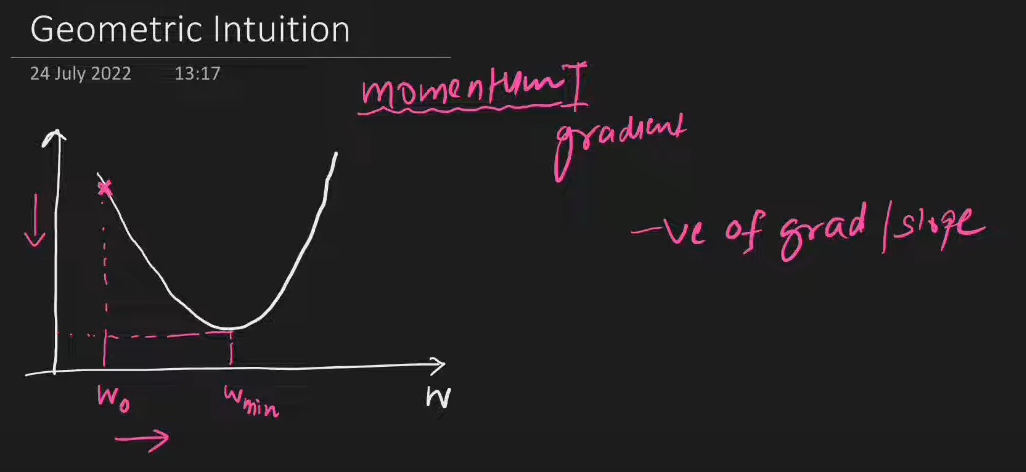

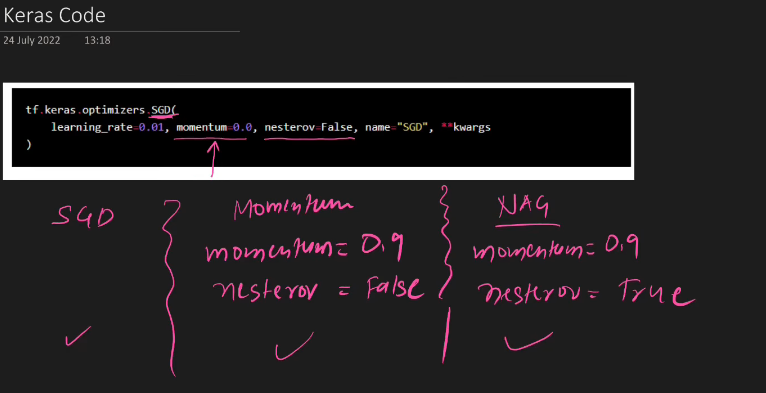

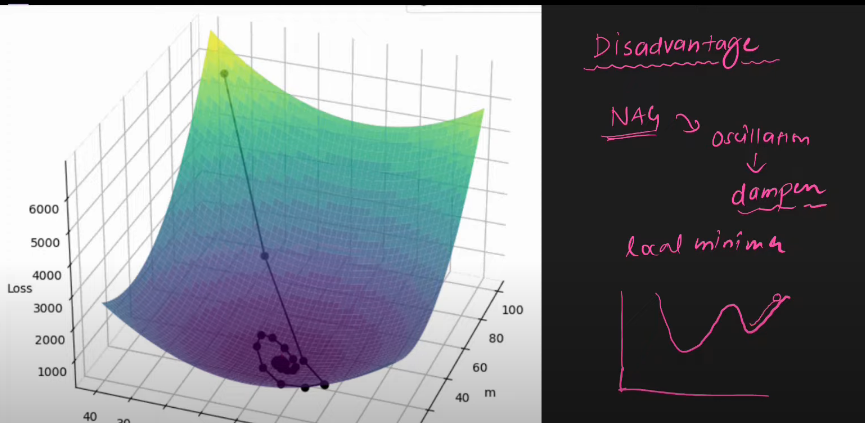

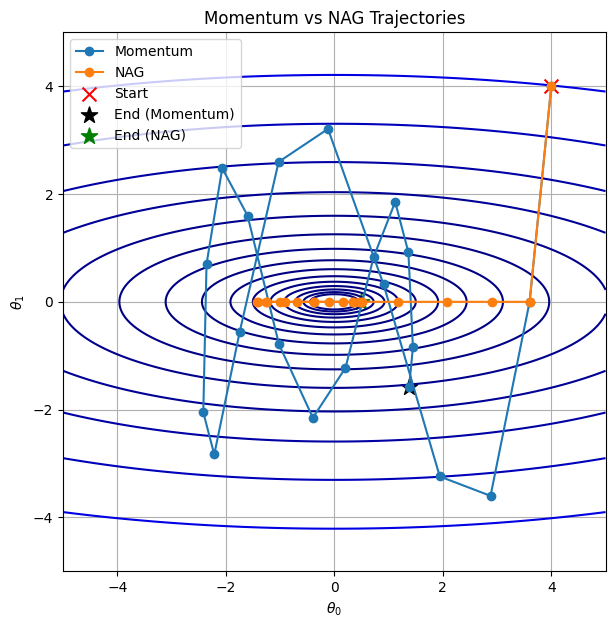

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -------- Loss and Gradient (elongated bowl) --------
def loss(theta):
    return 0.5 * (theta[0]**2 + 10 * theta[1]**2)

def grad(theta):
    return np.array([theta[0], 10 * theta[1]])

# -------- Optimizers --------
def sgd_momentum(theta, eta, mu, steps):
    v = np.zeros_like(theta)
    path = [theta.copy()]
    for _ in range(steps):
        g = grad(theta)
        v = mu * v - eta * g
        theta = theta + v
        path.append(theta.copy())
    return np.array(path)

def nag(theta, eta, mu, steps):
    v = np.zeros_like(theta)
    path = [theta.copy()]
    for _ in range(steps):
        lookahead = theta + mu * v
        g = grad(lookahead)
        v = mu * v - eta * g
        theta = theta + v
        path.append(theta.copy())
    return np.array(path)

# -------- Parameters --------
eta = 0.1     # learning rate
mu = 0.9      # momentum coefficient
steps = 20
theta0 = np.array([4.0, 4.0])

# -------- Run both methods --------
path_mom = sgd_momentum(theta0.copy(), eta, mu, steps)
path_nag = nag(theta0.copy(), eta, mu, steps)

# -------- Create contour plot --------
x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x, y)
Z = 0.5 * (X**2 + 10 * Y**2)

plt.figure(figsize=(7, 7))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='jet')

# Plot paths
plt.plot(path_mom[:,0], path_mom[:,1], 'o-', label='Momentum')
plt.plot(path_nag[:,0], path_nag[:,1], 'o-', label='NAG')

# Mark start and end
plt.scatter(path_mom[0,0], path_mom[0,1], c='red', marker='x', s=100, label='Start')
plt.scatter(path_mom[-1,0], path_mom[-1,1], c='black', marker='*', s=150, label='End (Momentum)')
plt.scatter(path_nag[-1,0], path_nag[-1,1], c='green', marker='*', s=150, label='End (NAG)')

plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.title("Momentum vs NAG Trajectories")
plt.legend()
plt.grid(True)
plt.show()


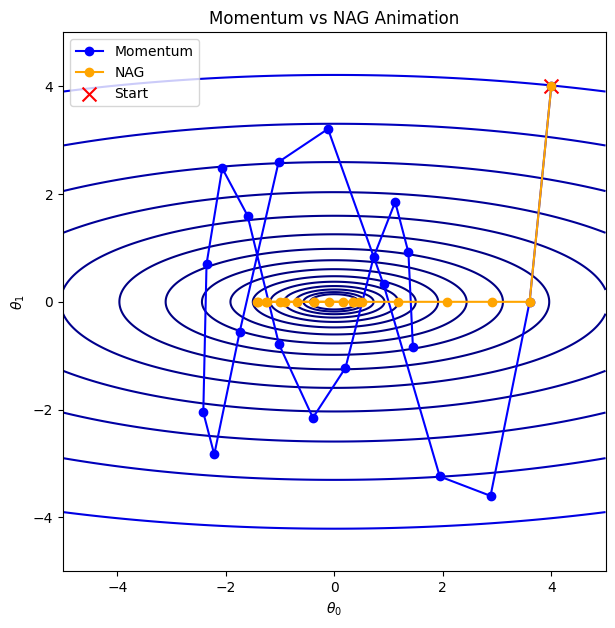

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# -------- Loss and Gradient (elongated bowl) --------
def loss(theta):
    return 0.5 * (theta[0]**2 + 10 * theta[1]**2)

def grad(theta):
    return np.array([theta[0], 10 * theta[1]])

# -------- Optimizers --------
def sgd_momentum_path(theta, eta, mu, steps):
    v = np.zeros_like(theta)
    path = [theta.copy()]
    for _ in range(steps):
        g = grad(theta)
        v = mu * v - eta * g
        theta = theta + v
        path.append(theta.copy())
    return np.array(path)

def nag_optimizer_path(theta, eta, mu, steps):
    v = np.zeros_like(theta)
    path = [theta.copy()]
    for _ in range(steps):
        lookahead = theta + mu * v
        g = grad(lookahead)
        v = mu * v - eta * g
        theta = theta + v
        path.append(theta.copy())
    return np.array(path)

# -------- Parameters --------
eta = 0.1
mu = 0.9
steps = 20
theta0 = np.array([4.0, 4.0])

# -------- Generate paths --------
mom_path = sgd_momentum_path(theta0.copy(), eta, mu, steps)
nag_path = nag_optimizer_path(theta0.copy(), eta, mu, steps)

# -------- Contour Plot Setup --------
x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x, y)
Z = 0.5 * (X**2 + 10 * Y**2)

fig, ax = plt.subplots(figsize=(7,7))
ax.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='jet')
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_title("Momentum vs NAG Animation")

mom_line, = ax.plot([], [], 'o-', color='blue', label='Momentum')
nag_line, = ax.plot([], [], 'o-', color='orange', label='NAG')

ax.scatter(mom_path[0,0], mom_path[0,1], c='red', marker='x', s=100, label='Start')
ax.legend()

# -------- Animation Function --------
def init():
    mom_line.set_data([], [])
    nag_line.set_data([], [])
    return mom_line, nag_line

def update(frame):
    mom_line.set_data(mom_path[:frame,0], mom_path[:frame,1])
    nag_line.set_data(nag_path[:frame,0], nag_path[:frame,1])
    return mom_line, nag_line

ani = animation.FuncAnimation(fig, update, frames=len(mom_path), init_func=init,
                               interval=500, blit=True, repeat=False)

# Display animation inline in Jupyter
HTML(ani.to_jshtml())




---

## **1. Working of NAG**

### **Step-by-step logic**

NAG is a momentum-based optimizer with a **look-ahead** step.

#### **Notation**

* $\theta_t$ = parameters
* $v_t$ = velocity (momentum term)
* $\eta$ = learning rate
* $\mu$ = momentum coefficient
* $g_t$ = gradient

#### **Algorithm**

1. **Look ahead** using the current momentum:

$$
\tilde{\theta} = \theta_{t-1} + \mu v_{t-1}
$$

2. **Compute gradient** at the look-ahead position:

$$
g_t = \nabla_\theta L(\tilde{\theta})
$$

3. **Update velocity**:

$$
v_t = \mu v_{t-1} - \eta g_t
$$

4. **Update parameters**:

$$
\theta_t = \theta_{t-1} + v_t
$$

---

### **Intuition**

* **Classical momentum:** Moves, then corrects direction based on gradient at the *current* point.
* **NAG:** Checks where momentum will take you first, then adjusts direction **before** moving.
* Effectively: “See the curve in the road and start steering early.”

---

### **Behavior on a Loss Surface**

* On an **elongated valley**:

  * Momentum overshoots less because the gradient is computed at the upcoming point.
  * The path to the minimum is smoother and faster.
* On **noisy surfaces**:

  * Slightly more robust because it anticipates direction changes.

---

## **2. Pros of NAG**

* **Better foresight:** Corrects course before overshooting.
* **Faster convergence** than plain momentum in many cases.
* **Less zigzagging** in narrow valleys.
* **Simple to implement** — just one extra “look-ahead” computation.

---

## **3. Cons / Drawbacks of NAG**

1. **Extra gradient computation (conceptually)**

   * In theory, NAG requires computing the gradient at the look-ahead position, which seems like extra work.
   * In practice, frameworks merge this into one computation, so cost is similar to momentum.

2. **Still sensitive to hyperparameters**

   * You still need to tune both $\eta$ (learning rate) and $\mu$ (momentum coefficient).
   * Wrong values can cause oscillations or divergence.

3. **No guarantee for non-convex problems**

   * Like momentum, NAG can still get stuck in poor local minima in non-convex landscapes.

4. **Can slow adaptation to sudden changes**

   * Because it uses accumulated momentum, if the loss surface changes sharply, it may take longer to adjust.

---

## **4. Typical Hyperparameters**

* $\mu$ (momentum): **0.9** is a common starting point.
* $\eta$ (learning rate): Slightly higher than plain SGD; e.g., 0.01–0.1 depending on the problem.

---

## **5. Key Difference from Classical Momentum**

| Feature               | Classical Momentum | NAG                 |
| --------------------- | ------------------ | ------------------- |
| Gradient evaluated at | Current position   | Look-ahead position |
| Correction timing     | After movement     | Before movement     |
| Overshoot risk        | Higher             | Lower               |
| Responsiveness        | Lower              | Higher              |

---




---

## **1. What is NAG?**

Nesterov Accelerated Gradient is an improved version of momentum-based SGD.
The key difference: instead of computing the gradient at the **current parameters**, NAG computes it at the **look-ahead position** — where momentum is about to take you.

**Idea:** “Don’t just run with momentum — peek ahead and adjust before you overshoot.”

---

## **2. Why NAG Exists**

**Problem with classical momentum:**

* You move based on old velocity and then correct with the new gradient.
* But by the time you compute the gradient, you’ve already moved — you’re always “late” with your correction.

**NAG’s solution:**

* Look ahead using momentum, get the gradient there, and then decide the correction.
* This makes the update more accurate and responsive.

---

## **3. The Update Rule**

Let:

* $\theta_t$ = parameters
* $v_t$ = velocity
* $\eta$ = learning rate
* $\mu$ = momentum coefficient
* $g_t = \nabla_\theta L(\theta)$ = gradient

**Steps:**

1. Look ahead:

$$
\tilde{\theta} = \theta_{t-1} + \mu v_{t-1}
$$

2. Compute gradient at look-ahead position:

$$
g_t = \nabla_\theta L(\tilde{\theta})
$$

3. Update velocity:

$$
v_t = \mu v_{t-1} - \eta g_t
$$

4. Update parameters:

$$
\theta_t = \theta_{t-1} + v_t
$$

---

## **4. Key Difference vs Classical Momentum**

| Step              | Classical Momentum | NAG                   |
| ----------------- | ------------------ | --------------------- |
| Gradient location | Current position   | Look-ahead position   |
| Responsiveness    | Slightly delayed   | More responsive       |
| Overshoot control | Lower              | Better (more precise) |

---

## **5. Intuition**

Imagine driving a car down a hill:

* **Classical momentum:** You steer based on where you are now — sometimes you react too late to a curve.
* **NAG:** You look ahead in the road, see the curve, and start adjusting earlier.

---

## **6. Numerical Example (1D Quadratic)**

Loss: $L(\theta) = \theta^2$, gradient $g = 2\theta$

* $\eta = 0.1$, $\mu = 0.9$, start at $\theta = 5.0$

**Step 1:**

* Look ahead: $\tilde{\theta} = 5.0 + 0.9*0 = 5.0$
* Gradient: $g = 10.0$
* Velocity: $v = 0.9*0 - 0.1*10 = -1.0$
* Update: $\theta = 5.0 - 1.0 = 4.0$

**Step 2:**

* Look ahead: $4.0 + 0.9*(-1.0) = 3.1$
* Gradient: $g = 6.2$
* Velocity: $v = -0.9 - 0.62 = -1.52$
* Update: $\theta = 4.0 - 1.52 = 2.48$

We’re correcting sooner, so we zigzag less.

---

## **7. Pros and Cons**

**Pros:**

* More accurate updates than classical momentum.
* Reduces overshooting in steep directions.
* Often converges faster in practice.

**Cons:**

* Slightly more computation (one extra gradient evaluation in the conceptual form, though in practice it’s merged so cost is similar).
* Still requires tuning η and μ.

---

## **8. Convex vs Non-Convex Behavior**

* **Convex:** Proven to converge faster than plain gradient descent and classical momentum in many cases.
* **Non-convex:** Still useful — helps smoother movement and escaping saddles, but no global guarantee.

---

